In [5]:
import os
os.environ["QT_API"] = "pyqt5"
os.environ["MNE_3D_OPTION_ANTIALIAS"] = "1"

In [6]:
import numpy as np
import mne
from mne.simulation import simulate_raw, simulate_sparse_stc, add_noise, add_eog
from mne import make_ad_hoc_cov

In [7]:

SFREQ        = 256        # Hz
DURATION_MIN = 5          # minutes
EPOCH_DUR    = 10.0       # seconds per tiled source epoch
N_DIPOLES    = 6          # sparse cortical sources
ALPHA_HZ     = 10.0       # dominant resting frequency
SEED         = 42
OUTPUT       = "resting_eeg_sphere_raw.fif"

rng = np.random.RandomState(SEED)

In [8]:
print("Building channel info …")

montage = mne.channels.make_standard_montage("standard_1020")
ch_names = ['Fp1','Fp2','F7','F3','Fz','F4','F8',
            'T7','C3','Cz','C4','T8',
            'P7','P3','Pz','P4','P8',
            'O1','O2']

info = mne.create_info(ch_names=ch_names, sfreq=SFREQ, ch_types="eeg")
raw = mne.io.RawArray(np.zeros((len(ch_names), 1)), info, verbose=False)
raw.set_montage(montage)
raw = raw.set_eeg_reference("average", projection=False, verbose=False)

Building channel info …


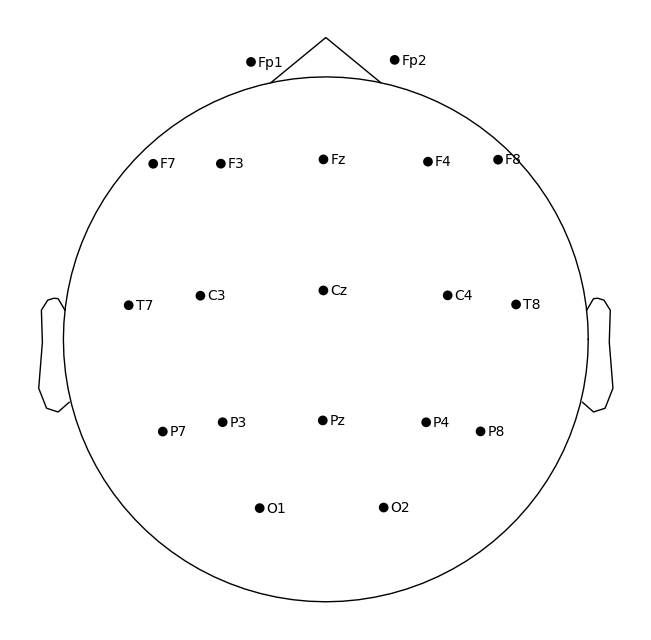

In [9]:
electrode_fig = raw.plot_sensors(show_names = True)

In [10]:
print("Building spherical conductor model …")
sphere = mne.make_sphere_model(
    r0=(0.0, 0.0, 0.0),       # centre of sphere (m, head coords)
    head_radius=0.09,          # outer skull radius
)


Building spherical conductor model …

Equiv. model fitting -> RV = 0.00347455 %%
mu1 = 0.944856    lambda1 = 0.136823
mu2 = 0.667779    lambda2 = 0.683693
mu3 = -0.294888    lambda3 = -0.0101468
Set up EEG sphere model with scalp radius    90.0 mm



In [11]:
print("Creating volume source space …")
src = mne.setup_volume_source_space(
    pos=15.0,                  # grid spacing in mm
    sphere=sphere,
    sphere_units="m",          # sphere object already in metres
    verbose=False,
)
print(f"  Source space: {src[0]['nuse']} active voxels")

Creating volume source space …
  Source space: 515 active voxels


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\2294434764.py:2: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(


In [12]:
print("Computing EEG forward solution (sphere) …")
fwd = mne.make_forward_solution(
    raw.info,
    trans=None,                # no head↔MRI transform needed for sphere
    src=src,
    bem=sphere,
    eeg=True,
    meg=False,
    verbose=False,
)
print(f"  Forward: {fwd['sol']['data'].shape} (channels × sources)")

Computing EEG forward solution (sphere) …
  Forward: (19, 1545) (channels × sources)


c:\Users\ingrambz\AppData\Local\mne-python\1.11.0_0\Lib\site-packages\mne\forward\_compute_forward.py:600: RuntimeWarning: divide by zero encountered in scalar divide
  rd2_inv = 1.0 / rd2
c:\Users\ingrambz\AppData\Local\mne-python\1.11.0_0\Lib\site-packages\mne\forward\_compute_forward.py:632: RuntimeWarning: invalid value encountered in multiply
  sphere["lambda"][eq]


In [17]:
trans = mne.transforms.Transform("head", "mri", np.eye(4))
mne.viz.plot_alignment(
    info=raw.info,
    bem=sphere,
    trans=trans,
    eeg=[ 'projected'],  # <-- was: eeg=True
    dig=True,
    surfaces='head',
)

Channel types::	eeg: 19
Projecting sensors to the head surface


In [23]:

src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)
mne.viz.plot_alignment(
    raw.info,
    trans=trans,
    eeg="projected",
    bem=sphere,
    src=src,
    dig=True,
    surfaces='head',
    show_axes=True,
)

Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 81.0 mm
grid                  : 10.0 mm
mindist               : 5.0 mm

Setting up the sphere...
Surface CM = (   0.0    0.0    0.0) mm
Surface fits inside a sphere with radius   81.0 mm
Surface extent:
    x =  -81.0 ...   81.0 mm
    y =  -81.0 ...   81.0 mm
    z =  -81.0 ...   81.0 mm
Grid extent:
    x =  -90.0 ...   90.0 mm
    y =  -90.0 ...   90.0 mm
    z =  -90.0 ...   90.0 mm
6859 sources before omitting any.
2205 sources after omitting infeasible sources not within 0.0 - 81.0 mm.
Source spaces are in MRI coordinates.
Checking that the sources are inside the surface and at least    5.0 mm away (will take a few...)
    366 source space point omitted because of the    5.0-mm distance limit.
1839 sources remaining after excluding the sources outside the surface and less than    5.0 mm inside.
Adjusting the neighborhood info.
Source space : MRI voxel -> MRI (surface RAS)
    0.010000 0.000000 0.000000    

C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\781427587.py:1: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  src = mne.setup_volume_source_space(sphere=sphere, pos=10.0)


Channel types::	eeg: 19
Projecting sensors to the head surface


### Simulate Data

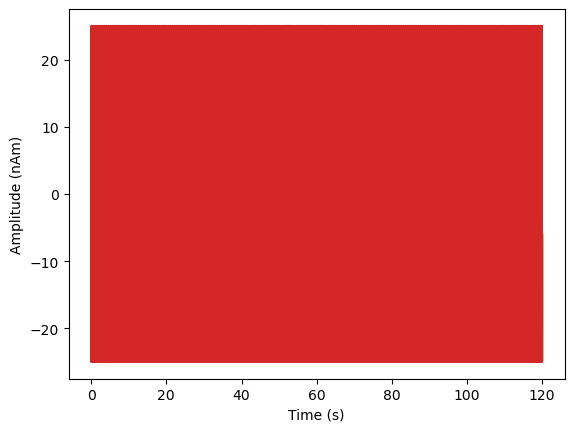

In [28]:
import matplotlib.pyplot as plt 
n_dipoles = 4  # number of dipoles to create
epoch_duration = 2.0  # duration of each epoch/event
n = 0  # harmonic number
rng = np.random.RandomState(0)  # random state (make reproducible)


def data_fun(times):
    return 25e-9 * np.sin(2 * np.pi * 10 * times)


sfreq = raw.info["sfreq"]  # sampling frequency (Hz)
duration = 120.0  # 2 minutes in seconds

n_samp = int(sfreq * duration)
times = np.arange(n_samp) / sfreq

src = fwd["src"]
stc = simulate_sparse_stc(
    src, n_dipoles=n_dipoles, times=times, data_fun=data_fun, random_state=rng
)

# look at our source data
fig, ax = plt.subplots(1)
ax.plot(times, 1e9 * stc.data.T)
ax.set(ylabel="Amplitude (nAm)", xlabel="Time (s)")
mne.viz.utils.plt_show()

In [62]:
stc = simulate_sparse_stc(
    fwd["src"],
    n_dipoles=1,
    times=times,
    data_fun=data_fun,
    random_state=0
)

In [63]:
raw.info

<Info | 9 non-empty values
 bads: []
 ch_names: Fp1, Fp2, F7, F3, Fz, F4, F8, T7, C3, Cz, C4, T8, P7, P3, Pz, ...
 chs: 19 EEG
 custom_ref_applied: True
 dig: 22 items (3 Cardinal, 19 EEG)
 highpass: 0.0 Hz
 lowpass: 128.0 Hz
 meas_date: unspecified
 nchan: 19
 projs: []
 sfreq: 256.0 Hz
>

In [59]:
info = raw.info.copy()
info["dev_head_t"] = fwd["info"]["dev_head_t"]
raw_sim = simulate_raw(info, [stc] * 10, forward=fwd, verbose=True)
cov = make_ad_hoc_cov(raw_sim.info)
add_noise(raw_sim, cov, iir_filter=[0.2, -0.2, 0.04], random_state=rng)
#add_ecg(raw_sim, random_state=rng)
add_eog(raw_sim, random_state=rng)

Setting up raw simulation: 1 position, "cos2" interpolation
Event information not stored
    Interval 0.000–120.000 s
Setting up forward solutions
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    Interval 0.000–120.000 s
    10 STC iterations provided
[done]
Adding noise to 19/19 channels (19 channels in cov)
Sphere                : origin at (0.0 0.0 0.0) mm
              radius  : 0.1 mm
Source location file  : dict()
Assuming input in millimeters
Assuming input in MRI coordinates

Positions (in meters) and orientations
2 sources
blink simulated and trace not stored
Setting up forward solutions


C:\Users\ingrambz\AppData\Local\Temp\ipykernel_30320\2403221597.py:7: RuntimeWarning: SUBJECTS_DIR in your MNE-Python configuration or environment does not exist, consider using mne.set_config to fix it: C:\Users\ingrambz\mne_data\MNE-fsaverage-data
  add_eog(raw_sim, random_state=rng)


In [60]:
raw_sim.plot()

<mne_qt_browser._pg_figure.MNEQtBrowser(0x263c4801c10) at 0x0000026409E51EC0>

Channels marked as bad:
none


Effective window size : 8.000 (s)


Plotting power spectral density (dB=True).


c:\Users\ingrambz\AppData\Local\mne-python\1.11.0_0\Lib\site-packages\mne\viz\utils.py:160: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  (fig or plt).show(**kwargs)


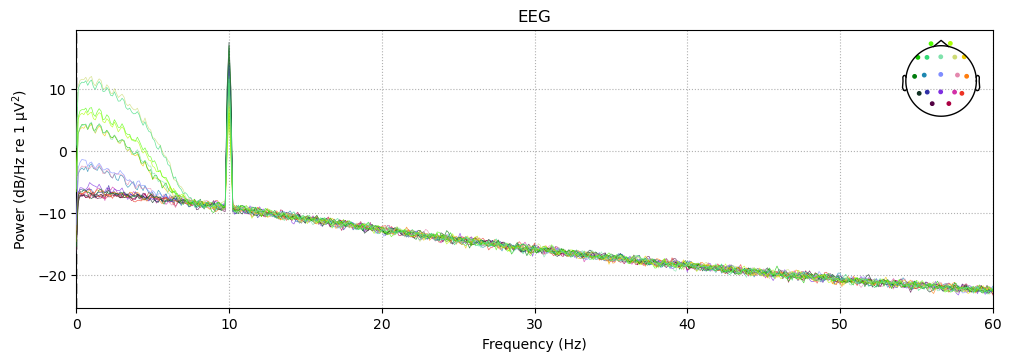

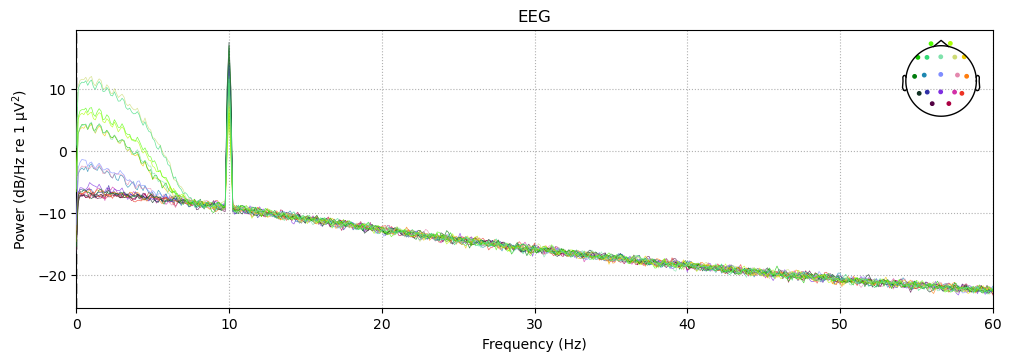

In [61]:
raw_sim.compute_psd(fmax = 60).plot(dB=True)